# ***Importing Libraries***

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.decomposition import PCA
from collections import Counter

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!pip install lime
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d448f684b936e06bcf09654ad48407c51bc9900a55c344cd593ed3aa30bff9e0
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
import shap

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
!pip install --upgrade scikit-learn xgboost

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
import numpy as np

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# ***Processing the dataset files***

# ***Processing data***

In [ ]:
firstdf = pd.read_csv('/content/Data.csv')
seconddf = pd.read_csv('/content/Data- Sustainable consumption intention in Vietnam.csv')

In [ ]:
firstdf.columns

Index(['SN', 'AT1', 'AT2', 'AT3', 'AT4', 'SN1', 'SN2', 'SN3', 'PBC1', 'PBC2',
       'PBC3', 'EO1', 'EO2', 'EO3', 'EC1', 'EC2', 'EC3', 'EC4', 'EC5', 'GPI1',
       'GPI2', 'GPI3', 'GPI4', 'GPB1', 'GPB2', 'GPB3', 'GPB4', 'GPB5', 'GPB6',
       'Gender', 'Age', 'Marital_Status', 'PB', 'EC', 'EO', 'PI', 'PBC', 'SNs',
       'ATT', 'CaseNo', 'ZPB', 'ZEC', 'ZEO', 'ZPI', 'ZPBC', 'ZSNs', 'ZATT',
       'EOXEC', 'ATTXSN', 'PBCXSN', 'ATTXPBC'],
      dtype='object')

In [ ]:
firstdf.head()

,SN,AT1,AT2,AT3,AT4,SN1,SN2,SN3,PBC1,PBC2,...,ZEC,ZEO,ZPI,ZPBC,ZSNs,ZATT,EOXEC,ATTXSN,PBCXSN,ATTXPBC
0,1,4,4,5,5,6,6,5,5,4,...,0.85722,-0.80271,0.83309,-0.08972,0.60682,-0.40293,-0.69,-0.24,-0.05,0.04
1,2,5,5,5,5,6,5,5,5,7,...,0.61720,-1.15998,0.86452,0.53753,0.40348,-0.16423,-0.72,-0.07,0.22,-0.09
2,3,5,6,5,5,4,4,4,4,6,...,-1.41293,-0.02443,1.25995,0.15288,-0.88163,-0.09448,0.03,0.08,-0.13,-0.01
3,4,6,6,6,6,6,5,5,6,5,...,0.81875,0.65115,0.75671,0.41231,0.41997,0.84748,0.53,0.36,0.17,0.35
4,5,6,7,6,6,6,7,6,7,6,...,0.47059,0.04687,1.30137,1.31930,1.25929,0.98800,0.02,1.24,1.66,1.30


# ***Processing Second Dataset***

In [ ]:
seconddf.head()

,STT,ATT1,ATT2,ATT3,ATT4,ATT5,SN1,SN2,SN3,SN4,...,AR1,AR2,AR3,AC1,AC2,AC3,IN1,IN2,IN3,IN4
0,1,4,5,4,4,3,4,4,4,5,...,5,5,5,5,5,4,3,3,3,3
1,2,4,4,3,4,3,3,4,4,4,...,3,3,4,4,4,3,4,3,4,3
2,3,4,5,4,5,4,3,3,4,3,...,4,4,5,4,4,4,5,5,5,5
3,4,4,5,5,5,4,4,4,4,3,...,2,3,2,5,5,5,4,4,4,3
4,5,4,5,5,4,5,4,3,3,4,...,4,4,4,5,5,4,4,5,5,5


# ***Preparing the first dataset ***

#***Finding appropriate feature and target columns***

In [ ]:
firstdf['GPI_GPB_Composite'] = firstdf[['GPI1', 'GPI2', 'GPI3', 'GPI4', 'GPB1', 'GPB2', 'GPB3', 'GPB4', 'GPB5', 'GPB6']].mean(axis=1)

# ** *Finding* appropriate threshold value to address the target variable**

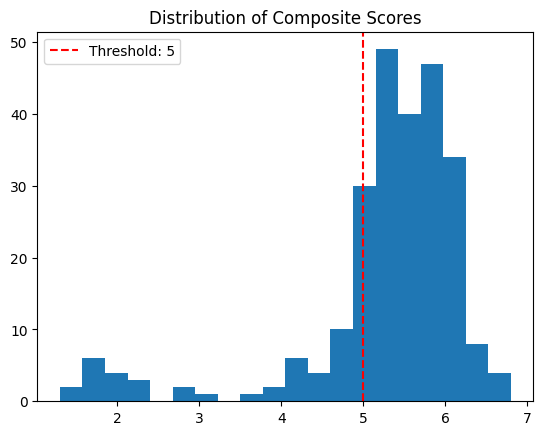

In [ ]:
plt.hist(firstdf['GPI_GPB_Composite'], bins=20)
plt.axvline(5, color='red', linestyle='--', label='Threshold: 5')
plt.legend()
plt.title('Distribution of Composite Scores')
plt.show()

In [ ]:
print(firstdf['GPI_GPB_Composite'].value_counts())

GPI_GPB_Composite
5.6    23
5.4    18
5.3    18
5.5    17
5.7    17
5.8    16
5.9    14
5.2    13
5.1    13
6.2    12
6.1    12
6.0    10
4.9     9
5.0     8
4.8     8
6.4     6
4.5     3
2.2     3
1.9     2
1.8     2
1.3     2
6.3     2
4.2     2
1.6     2
4.7     2
2.8     2
4.1     2
1.7     2
4.3     2
3.9     2
6.6     2
3.1     1
2.1     1
4.4     1
3.5     1
6.7     1
6.8     1
2.0     1
Name: count, dtype: int64


In [ ]:
median = firstdf['GPI_GPB_Composite'].median()
print(median)

5.5


In [ ]:
threshold = 5.5
firstdf['GPI_GPB_Category'] = firstdf['GPI_GPB_Composite'].apply(lambda x: 1 if x >= threshold else 0)

# ***First Dataset Class Distribution***

<ipython-input-28-c498a21aac91>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='GPI_GPB_Category'>

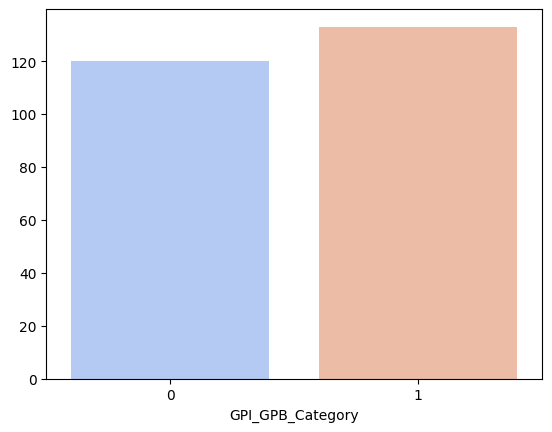

In [ ]:
sns.barplot(
    x=firstdf['GPI_GPB_Category'].value_counts().index,
    y=firstdf['GPI_GPB_Category'].value_counts().values,
    palette='coolwarm'
)

<ipython-input-29-17aab10022e0>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


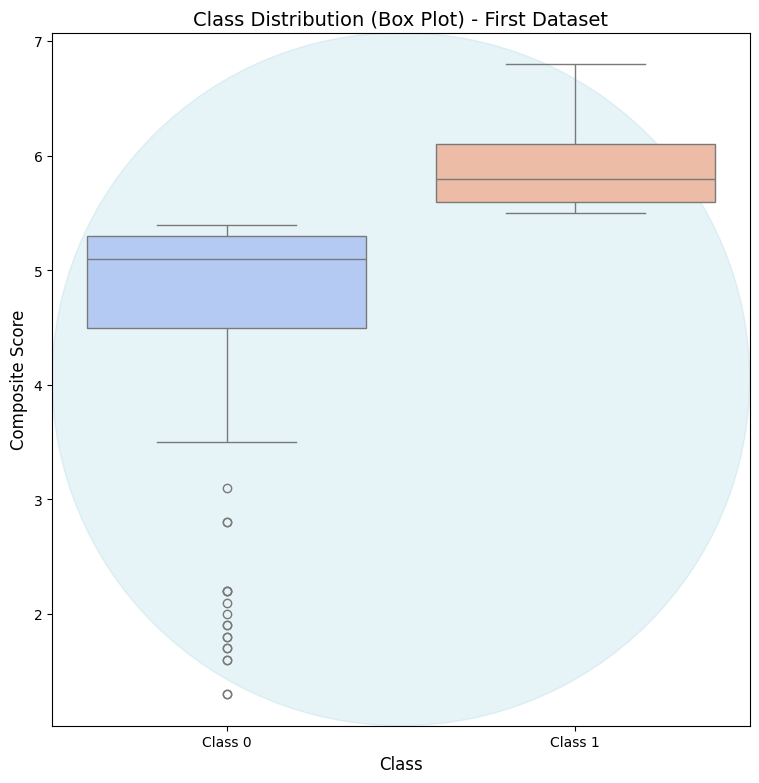

In [ ]:
plt.figure(figsize=(9, 9))
ax = plt.gca()
circle = plt.Circle((0.5, 0.5), 0.5, transform=ax.transAxes, color='lightblue', alpha=0.3, zorder=0)
ax.add_artist(circle)
sns.boxplot(
    y=firstdf['GPI_GPB_Composite'],
    x=firstdf['GPI_GPB_Category'],
    palette='coolwarm'
)
plt.title('Class Distribution (Box Plot) - First Dataset', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Composite Score', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Class 0', 'Class 1'])
plt.grid(False)
plt.show()

In [ ]:
features = ['AT1', 'AT2', 'AT3', 'AT4', 'SN1', 'SN2', 'SN3', 'PBC1', 'PBC2',
       'PBC3', 'EO1', 'EO2', 'EO3', 'EC1', 'EC2', 'EC3', 'EC4', 'EC5',
       'Gender', 'Age', 'Marital_Status', 'PB', 'EC', 'EO', 'PI', 'PBC', 'SNs',
       'ATT', 'CaseNo', 'ZPB', 'ZEC', 'ZEO', 'ZPI', 'ZPBC', 'ZSNs', 'ZATT',
       'EOXEC', 'ATTXSN', 'PBCXSN', 'ATTXPBC'
]

In [ ]:
X = firstdf[features]
y = firstdf['GPI_GPB_Category']

# ***Splitting the dataset into training and testing sets***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

In [ ]:
print("Logistic Regression Results for First Dataset:")
print("\nTraining Set Performance:")
print(classification_report(y_train, y_train_pred))
print("\nTesting Set Performance:")
print(classification_report(y_test, y_test_pred))

# ROC-AUC
y_test_proba = lr_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC Score (Test Set): {roc_auc_score(y_test, y_test_proba):.2f}")

Logistic Regression Results for First Dataset:

Training Set Performance:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        81
           1       0.97      0.99      0.98        96

    accuracy                           0.98       177
   macro avg       0.98      0.98      0.98       177
weighted avg       0.98      0.98      0.98       177


Testing Set Performance:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        39
           1       0.91      0.86      0.89        37

    accuracy                           0.89        76
   macro avg       0.90      0.89      0.89        76
weighted avg       0.90      0.89      0.89        76


ROC-AUC Score (Test Set): 0.98


# ***Random Forest Classifier***

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# ***Evaluation***

In [ ]:
print("\nRandom Forest Classifier Results:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Classifier Results:
Confusion Matrix:
 [[34  5]
 [ 0 37]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93        39
           1       0.88      1.00      0.94        37

    accuracy                           0.93        76
   macro avg       0.94      0.94      0.93        76
weighted avg       0.94      0.93      0.93        76

Accuracy: 0.9342105263157895


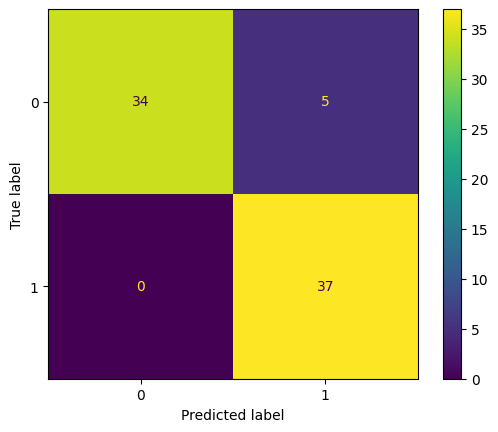

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test and y_pred_rf are defined from your previous code
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# ***Decision Tree Classifier***

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
print("\nDecision Tree Classifier Results:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classifier Results:
Confusion Matrix:
 [[37  2]
 [ 6 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90        39
           1       0.94      0.84      0.89        37

    accuracy                           0.89        76
   macro avg       0.90      0.89      0.89        76
weighted avg       0.90      0.89      0.89        76

Accuracy: 0.8947368421052632


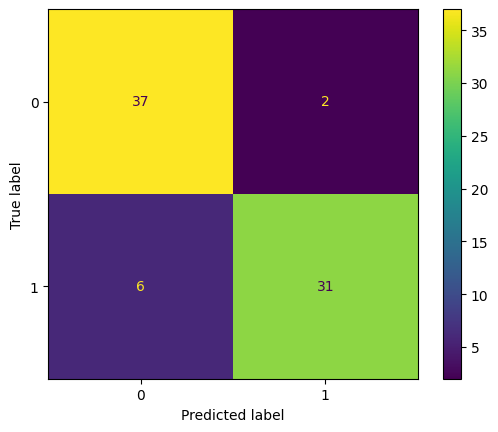

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test and y_pred_dt are defined from your previous code
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# ***Logistic Regression: Calculate Accuracy***


In [ ]:
train_accuracy_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_accuracy_rf = accuracy_score(y_test, rf_model.predict(X_test))

In [ ]:
train_accuracy_lr = accuracy_score(y_train, lr_model.predict(X_train))
test_accuracy_lr = accuracy_score(y_test, lr_model.predict(X_test))

#*** Decision Tree Classifier: Calculate Accuracy***

In [ ]:
train_accuracy_dt = accuracy_score(y_train, dt_model.predict(X_train))
test_accuracy_dt = accuracy_score(y_test, dt_model.predict(X_test))

In [ ]:
models = ['Logistic Regression', 'Decision Tree']
train_accuracies = [train_accuracy_lr, train_accuracy_dt]
test_accuracies = [test_accuracy_lr, test_accuracy_dt]

In [ ]:
def plot_learning_curve(estimator, X, y, title, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plots the learning curve for a given model and dataset.

    Parameters:
        estimator: The model (Logistic Regression, Decision Tree, Random Forest, etc.)
        X: Features
        y: Target
        title: Title of the plot
        cv: Cross-validation splits
        scoring: Scoring metric (default: accuracy)
        train_sizes: Proportions of training data to use for generating the learning curve
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, train_sizes=train_sizes, n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

    plt.title(title, fontsize=14)
    plt.xlabel('Training Samples', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 clas

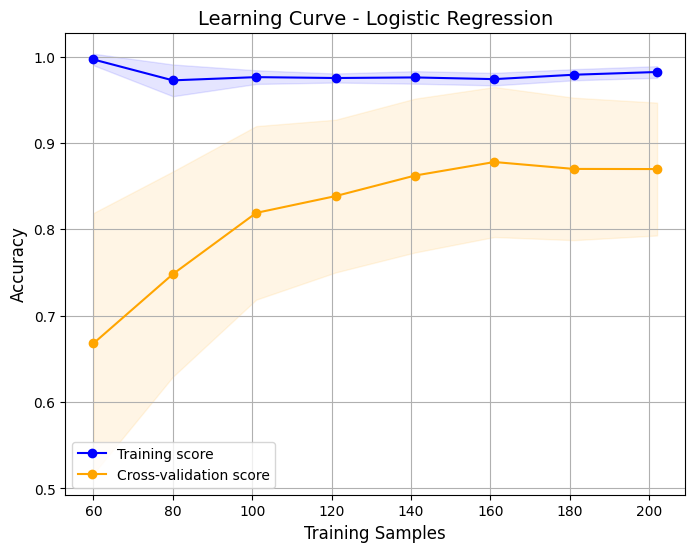

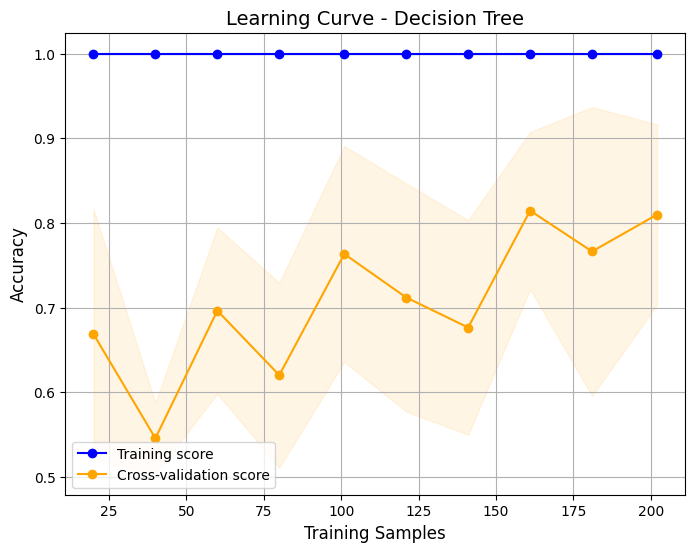

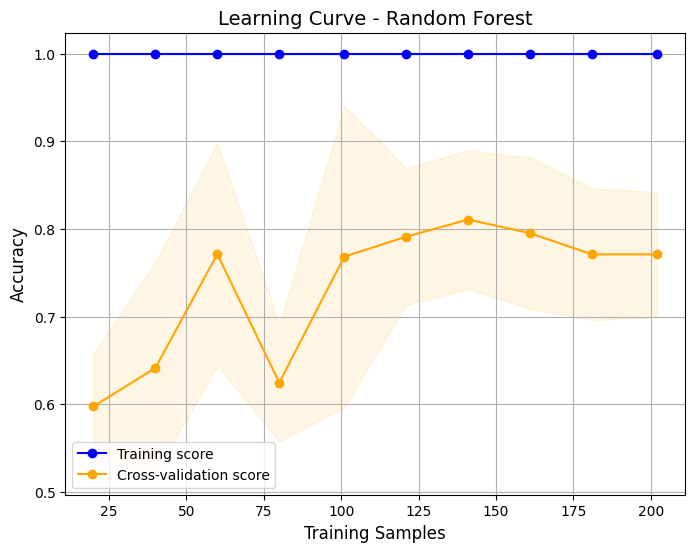

In [ ]:

plot_learning_curve(lr_model, X, y, title='Learning Curve - Logistic Regression')

plot_learning_curve(dt_model, X, y, title='Learning Curve - Decision Tree')

plot_learning_curve(rf_model, X, y, title='Learning Curve - Random Forest')

# ***Implementing decision tree regressor and gradient boosting regressor***

In [ ]:
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_dt = dt_regressor.predict(X_test)

In [ ]:
r2_dt = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f"Decision Tree Regressor - R² Score: {r2_dt:.3f}, MSE: {mse_dt:.3f}")

Decision Tree Regressor - R² Score: 0.579, MSE: 0.105


In [ ]:
gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
y_pred_gb = gb_regressor.predict(X_test)

In [ ]:
r2_gb = r2_score(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
print(f"Gradient Boosting Regressor - R² Score: {r2_gb:.3f}, MSE: {mse_gb:.3f}")

Gradient Boosting Regressor - R² Score: 0.756, MSE: 0.061


In [ ]:
def plot_learning_curve(estimator, X, y, cv=5, scoring='r2', title='Learning Curve', train_sizes=np.linspace(0.1, 1.0, 10)):
    plt.figure(figsize=(10, 6))


    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, train_sizes=train_sizes, n_jobs=-1
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)


    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color='blue', alpha=0.2)

    plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validation Score')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, color='green', alpha=0.2)


    plt.title(title, fontsize=14)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

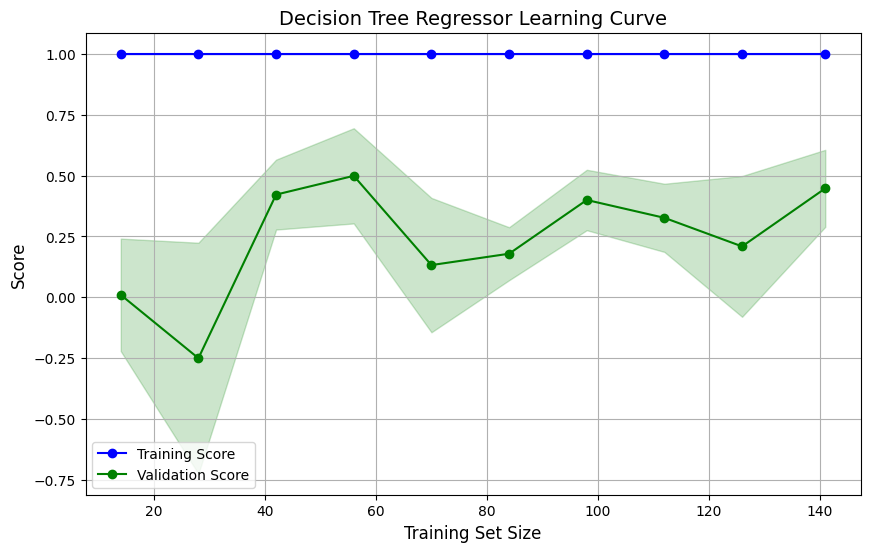

In [ ]:
plot_learning_curve(dt_regressor, X_train, y_train, cv=5, title='Decision Tree Regressor Learning Curve')

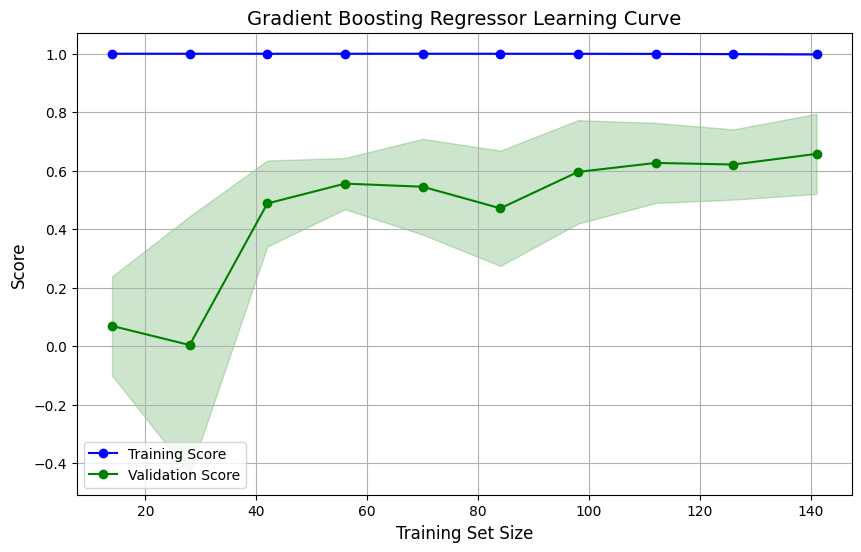

In [ ]:
plot_learning_curve(gb_regressor, X_train, y_train, cv=5, title='Gradient Boosting Regressor Learning Curve')

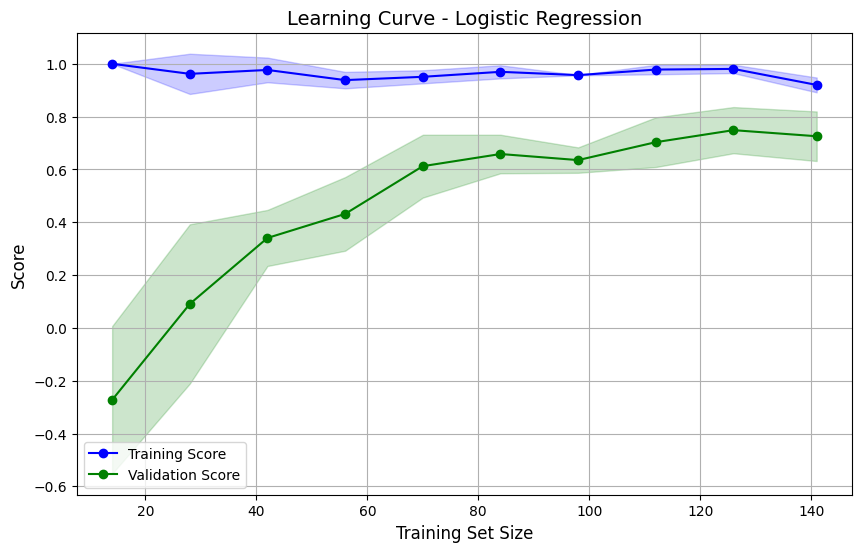

In [ ]:
plot_learning_curve(lr_model, X_train, y_train, cv=5, title='Learning Curve - Logistic Regression')

# ***Confusion Matrix for Logistic Regressor***

In [ ]:
y_test_pred_class = (lr_model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_class)

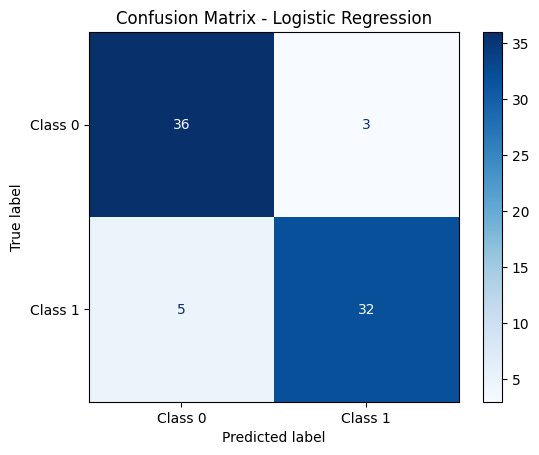

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ***Studying accuracies of the implemented models***

In [ ]:
model_names = [
    'Logistic Regression',
    'Decision Tree Classifier',
    'Random Forest Classifier',
    'Decision Tree Regressor',
    'Gradient Boosting Regressor'
]

In [ ]:
train_accuracies = [
    train_accuracy_lr,
    train_accuracy_dt,
    train_accuracy_rf,
    None,
    None
]

In [ ]:
test_accuracies = [
    test_accuracy_lr,
    test_accuracy_dt,
    test_accuracy_rf,
    r2_dt,
    r2_gb
]

In [ ]:
data = {
    'Model': model_names,
    'Training Accuracy': train_accuracies,
    'Testing Accuracy': test_accuracies
}

In [ ]:
accuracy_df = pd.DataFrame(data)

In [ ]:
accuracy_melted = accuracy_df.melt(id_vars='Model', var_name='Set', value_name='Accuracy')

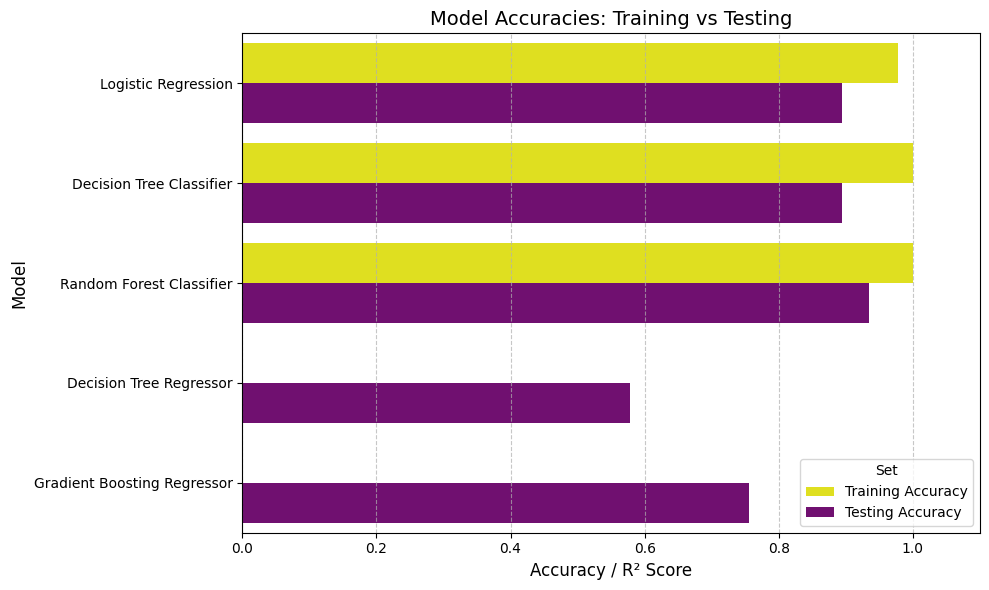

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=accuracy_melted,
    y='Model',
    x='Accuracy',
    hue='Set',
    palette=['yellow', 'purple']
)

plt.title('Model Accuracies: Training vs Testing', fontsize=14)
plt.xlabel('Accuracy / R² Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.1)
plt.legend(title='Set', fontsize=10, loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()


plt.show()

# ***Experimenting with XAI***

In [ ]:
lime_explainer_first = LimeTabularExplainer(
    X_train.values,
    training_labels=y_train.values,
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1'],
    discretize_continuous=True
)


In [ ]:
lime_exp_first = lime_explainer_first.explain_instance(
    X_test.iloc[0].values,
    lr_model.predict_proba
)


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
lime_exp_first.show_in_notebook()

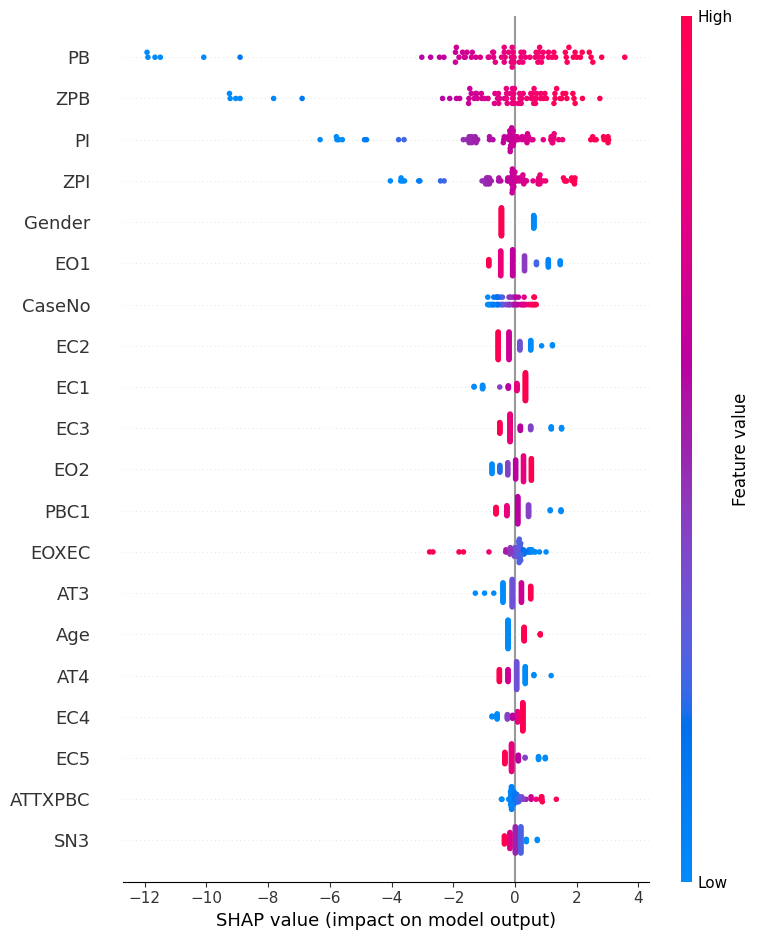

In [ ]:
shap_explainer_first = shap.Explainer(lr_model, X_train)
shap_values_first = shap_explainer_first(X_test)
shap.summary_plot(shap_values_first, X_test)

# ***Working with the second dataset's columns***

In [ ]:
seconddf.columns

Index(['STT', 'ATT1', 'ATT2', 'ATT3', 'ATT4', 'ATT5', 'SN1', 'SN2', 'SN3',
       'SN4', 'PBC1', 'PBC2 ', 'PBC3', 'PN1', 'PN2', 'PN3', 'PN4', 'AR1',
       'AR2', 'AR3', 'AC1', 'AC2', 'AC3', 'IN1', 'IN2', 'IN3', 'IN4'],
      dtype='object')

In [ ]:
pca = PCA(n_components=1)
seconddf['PCA_Intention'] = pca.fit_transform(seconddf[['IN1', 'IN2', 'IN3', 'IN4']])
seconddf['IN_INTENTION'] = (seconddf['PCA_Intention'] >= pca.components_.mean()).astype(int)

# ***Splitting features and target***

In [ ]:
X = seconddf.drop(columns=['STT', 'IN_INTENTION', 'IN1', 'IN2', 'IN3', 'IN4'])
y = seconddf['IN_INTENTION']

In [ ]:
print("Class distribution before SMOTE:", Counter(y))

Class distribution before SMOTE: Counter({0: 367, 1: 184})


<ipython-input-195-886448477e2c>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=barplot_data, x='Count', y='Class', palette=colors, orient='h')


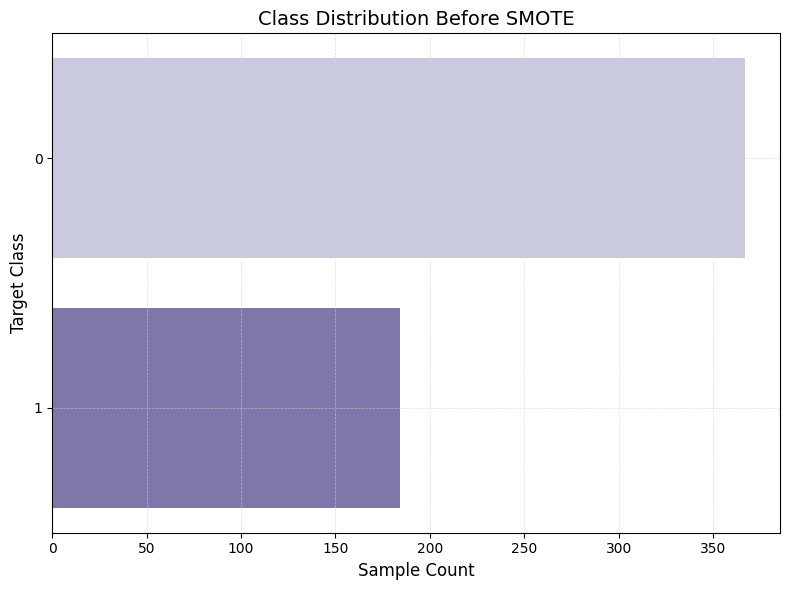

In [ ]:
plt.figure(figsize=(8, 6))
colors = sns.color_palette("Purples", n_colors=2)
barplot_data = pd.DataFrame({
    'Class': [0, 1],
    'Count': y.value_counts().sort_index()
})
sns.barplot(data=barplot_data, x='Count', y='Class', palette=colors, orient='h')
plt.title("Class Distribution Before SMOTE", fontsize=14)
plt.xlabel("Sample Count", fontsize=12)
plt.ylabel("Target Class", fontsize=12)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [ ]:
print("Class distribution after SMOTE:", Counter(y_resampled))

Class distribution after SMOTE: Counter({0: 367, 1: 367})


<ipython-input-198-e5bb66552b1b>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=barplot_data_resampled, x='Count', y='Class', palette=gradient_colors, orient='h')


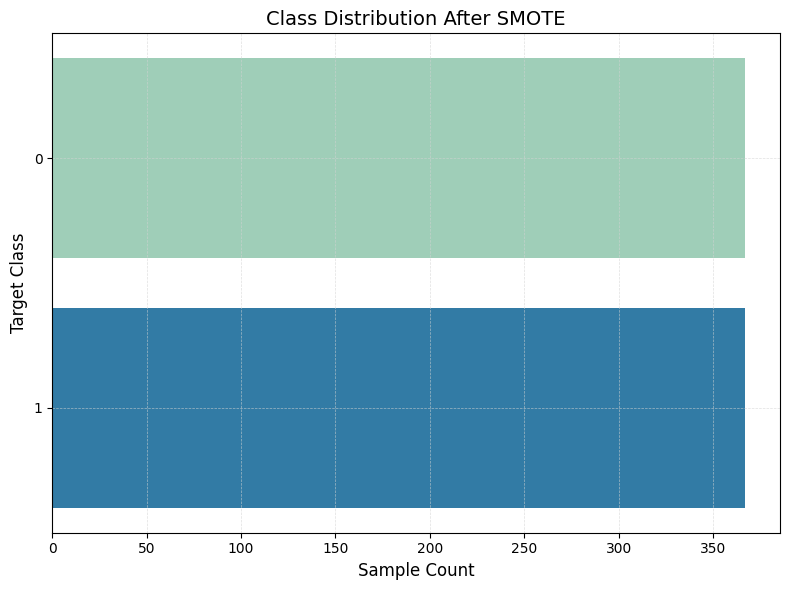

In [ ]:
plt.figure(figsize=(8, 6))
gradient_colors = sns.color_palette("YlGnBu", n_colors=2)
barplot_data_resampled = pd.DataFrame({
    'Class': [0, 1],
    'Count': pd.Series(y_resampled).value_counts().sort_index()
})
sns.barplot(data=barplot_data_resampled, x='Count', y='Class', palette=gradient_colors, orient='h')
plt.title("Class Distribution After SMOTE", fontsize=14)
plt.xlabel("Sample Count", fontsize=12)
plt.ylabel("Target Class", fontsize=12)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# ***Splitting into train-test sets***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# ***Decision Tree Classifier***

# ***Logistic Regressor***

# ***Random Forest Classifier***

# ***DT and GB regressors***

In [ ]:
def plot_learning_curve(estimator, X, y, title, scoring='accuracy', cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, n_jobs=-1, scoring=scoring
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', label='Training Score', color='blue')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, 'o-', label='Validation Score', color='orange')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

    plt.title(title, fontsize=14)
    plt.xlabel('Training Sizes', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_lr_proba = lr_model.predict_proba(X_test)[:, 1]
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr_proba))
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.9931972789115646
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        74
           1       1.00      0.99      0.99        73

    accuracy                           0.99       147
   macro avg       0.99      0.99      0.99       147
weighted avg       0.99      0.99      0.99       147



In [ ]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("\nDecision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Classifier:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        73

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147



In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_proba = rf_model.predict_proba(X_test)[:, 1]
print("\nRandom Forest Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_proba))
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier:
Accuracy: 1.0
ROC-AUC: 0.9999999999999999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        73

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147



In [ ]:
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)
y_pred_dt_reg = dt_regressor.predict(X_test)
print("\nDecision Tree Regressor:")
print("R² Score:", r2_score(y_test, y_pred_dt_reg))
print("MSE:", mean_squared_error(y_test, y_pred_dt_reg))


Decision Tree Regressor:
R² Score: 1.0
MSE: 0.0


In [ ]:
rf_regressor = RandomForestRegressor(random_state=42, n_estimators=100)
rf_regressor.fit(X_train, y_train)
y_pred_rf_reg = rf_regressor.predict(X_test)
print("\nRandom Forest Regressor:")
print("R² Score:", r2_score(y_test, y_pred_rf_reg))
print("MSE:", mean_squared_error(y_test, y_pred_rf_reg))


Random Forest Regressor:
R² Score: 1.0
MSE: 0.0


In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
]

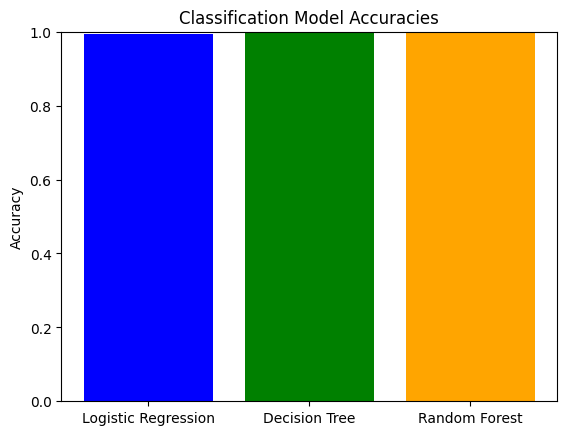

In [ ]:
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.title('Classification Model Accuracies')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

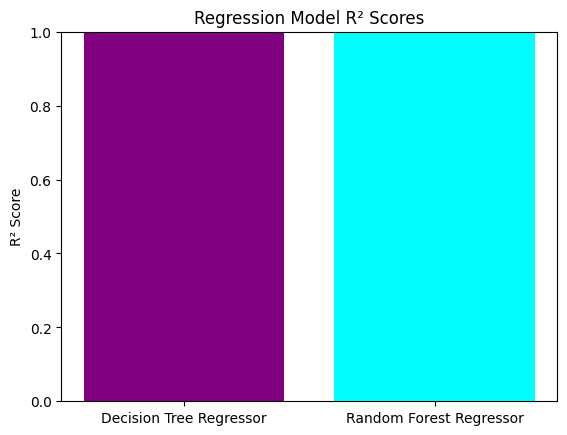

In [ ]:
reg_models = ['Decision Tree Regressor', 'Random Forest Regressor']
r2_scores = [
    r2_score(y_test, y_pred_dt_reg),
    r2_score(y_test, y_pred_rf_reg),
]
plt.bar(reg_models, r2_scores, color=['purple', 'cyan'])
plt.title('Regression Model R² Scores')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.show()

In [ ]:
gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train, y_train)
y_pred_gb_reg = gb_regressor.predict(X_test)
print("\nGradient Boosting Regressor:")
print("R² Score:", r2_score(y_test, y_pred_gb_reg))
print("MSE:", mean_squared_error(y_test, y_pred_gb_reg))


Gradient Boosting Regressor:
R² Score: 0.999999999294441
MSE: 1.7638157764467858e-10


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 clas

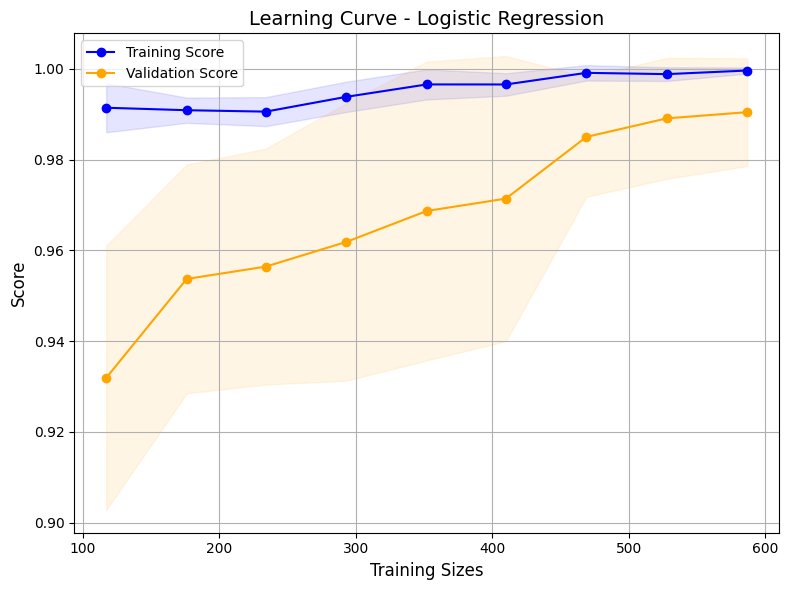

In [ ]:
plot_learning_curve(LogisticRegression(random_state=42, max_iter=1000), X_resampled, y_resampled, title='Learning Curve - Logistic Regression')

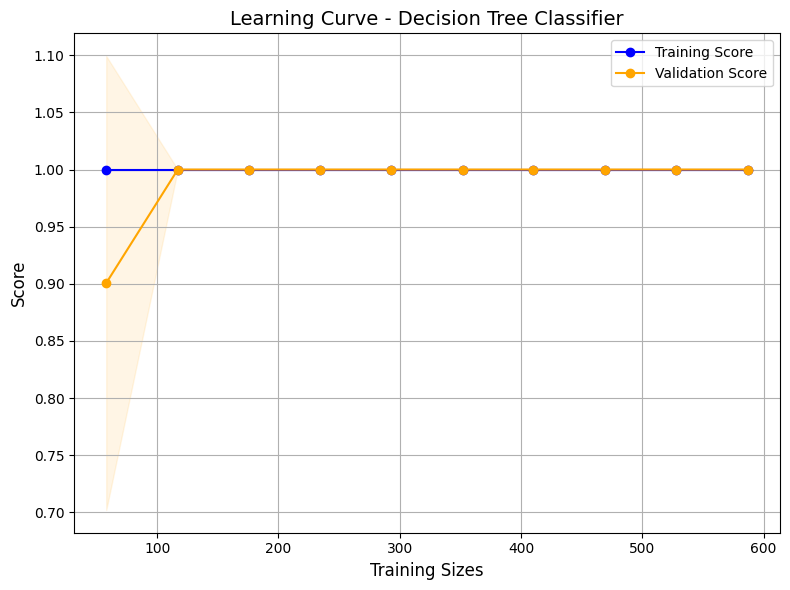

In [ ]:

# Decision Tree Classifier Learning Curve
plot_learning_curve(DecisionTreeClassifier(random_state=42), X_resampled, y_resampled, title='Learning Curve - Decision Tree Classifier')


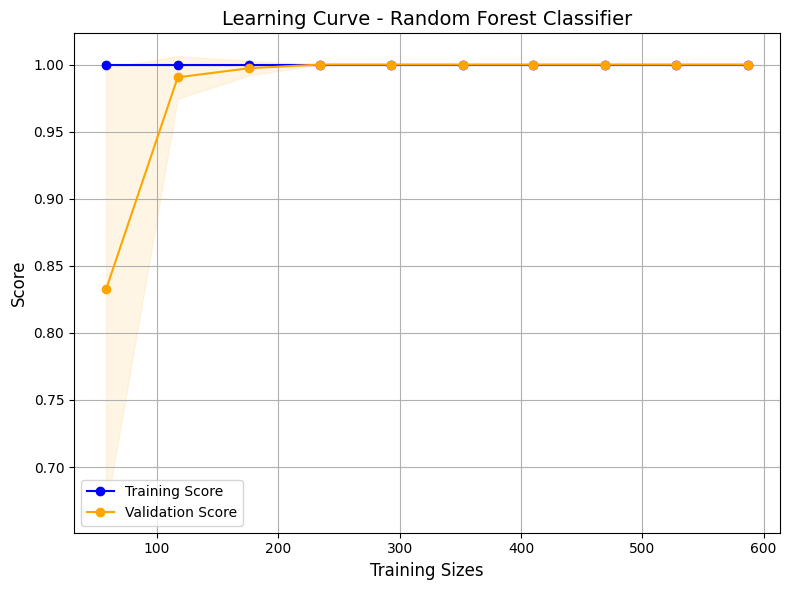

In [ ]:

# Random Forest Classifier Learning Curve
plot_learning_curve(RandomForestClassifier(random_state=42, n_estimators=100), X_resampled, y_resampled, title='Learning Curve - Random Forest Classifier')


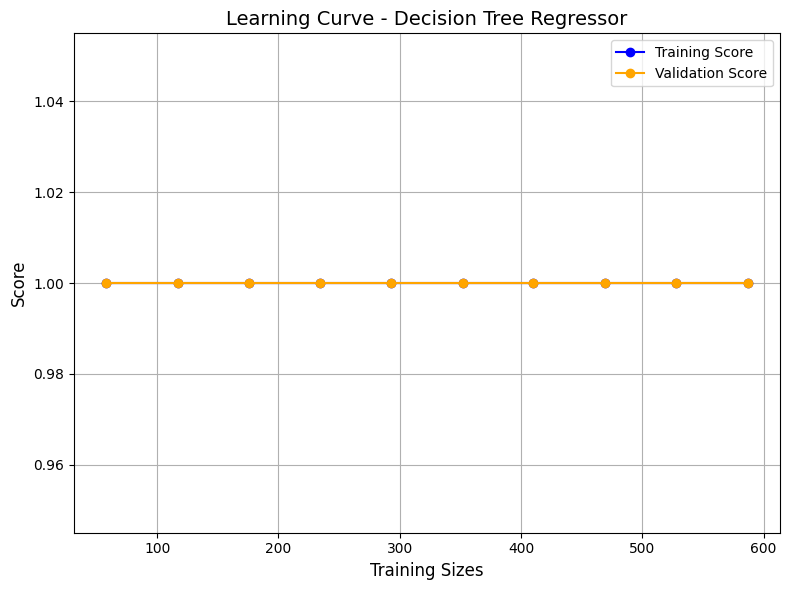

In [ ]:

# Decision Tree Regressor Learning Curve
plot_learning_curve(DecisionTreeRegressor(random_state=42), X_resampled, y_resampled, title='Learning Curve - Decision Tree Regressor', scoring='r2')



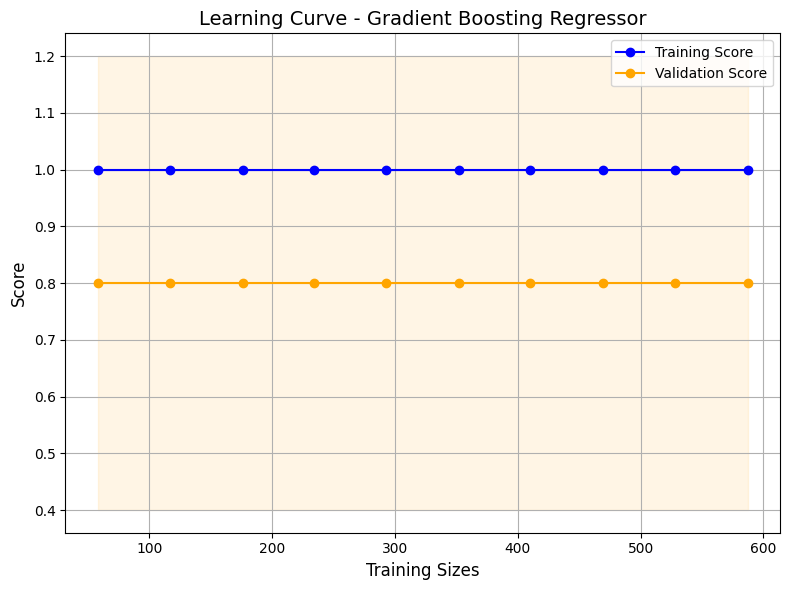

In [ ]:
# Gradient Boosting Regressor Learning Curve
plot_learning_curve(GradientBoostingRegressor(random_state=42), X_resampled, y_resampled, title='Learning Curve - Gradient Boosting Regressor', scoring='r2')

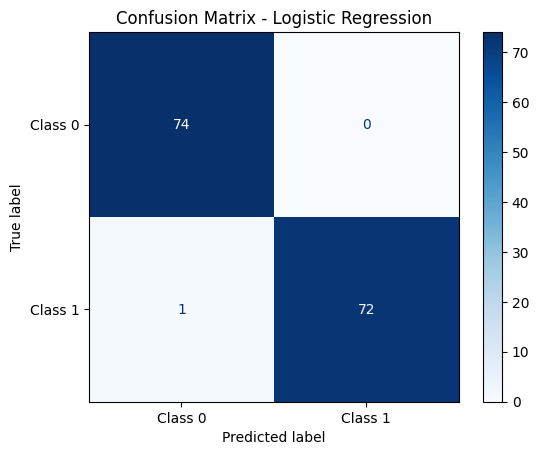

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ***Working with the explainable AIs***

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


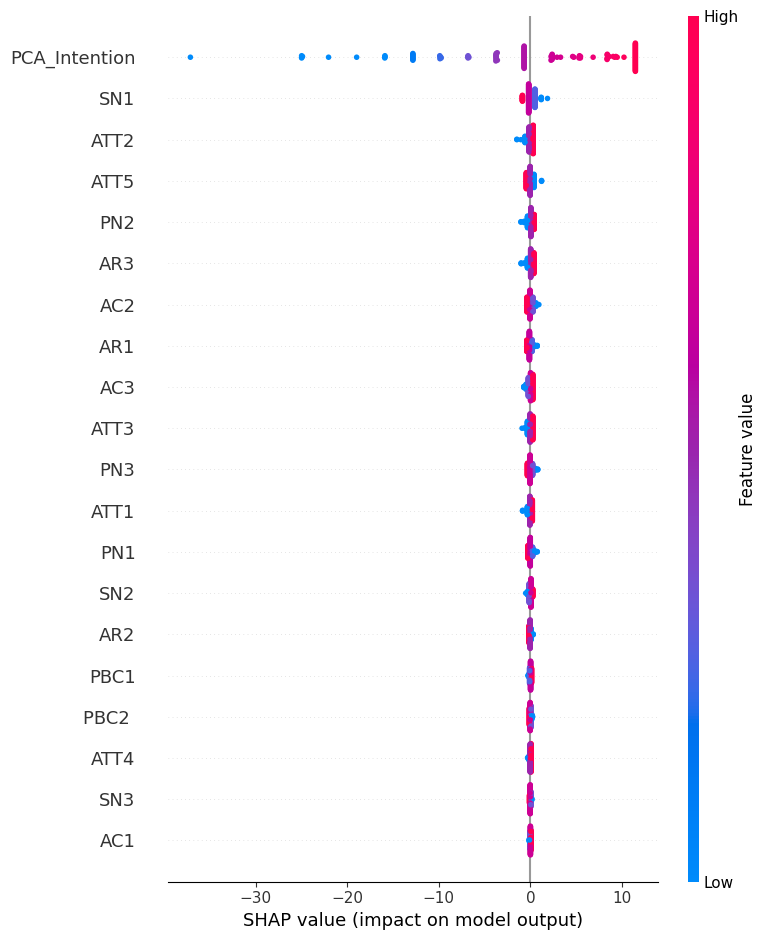

In [ ]:
# LIME for Logistic Regression
lime_explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, mode='classification', feature_names=X_train.columns, class_names=['Class 0', 'Class 1'], discretize_continuous=True)
idx = 0
lime_exp = lime_explainer.explain_instance(X_test.values[idx], lr_model.predict_proba)
lime_exp.show_in_notebook()

# SHAP for Logistic Regression
shap_explainer = shap.Explainer(lr_model, X_train)
shap_values = shap_explainer(X_test)
shap.summary_plot(shap_values, X_test)

# ***The logistic regression implemented with optimisiers through grid search results in an overfit learning curve in the testing phase with the second dataframe. Trying out optimisers via grid search technique resulted in unchanged learning curves and some of them became better (decision tree) and some became worse(logistic regression) however the main target was to identify green purchase intentions or behaviour which leads us to pick logistic regression as a suitable algorithm***

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Logistic Regression Results for First Dataset:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        39
           1       0.91      0.86      0.89        37

    accuracy                           0.89        76
   macro avg       0.90      0.89      0.89        76
weighted avg       0.90      0.89      0.89        76


Random Forest Results for First Dataset:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        39
           1       0.90      1.00      0.95        37

    accuracy                           0.95        76
   macro avg       0.95      0.95      0.95        76
weighted avg       0.95      0.95      0.95        76


Decision Tree Results for First Dataset:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        39
           1       0.85      0.95      0.90        37

    accuracy                           0.89       

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 clas

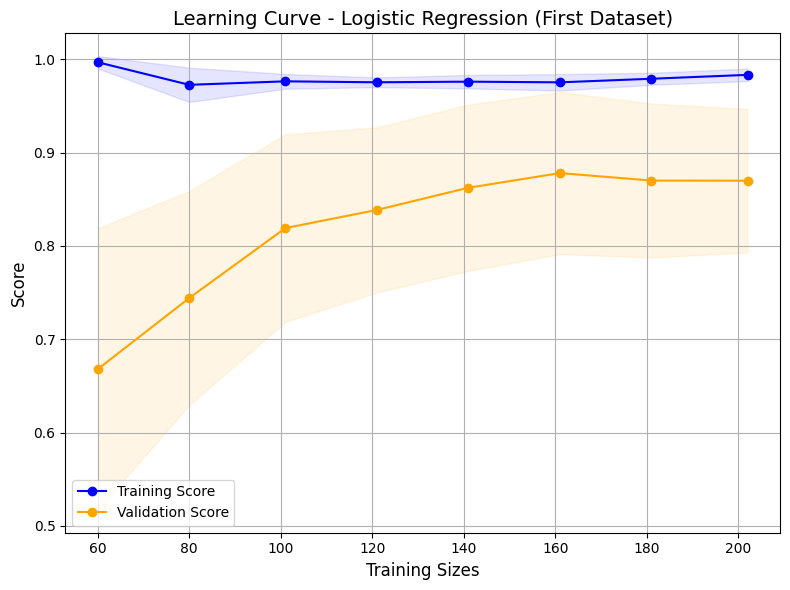

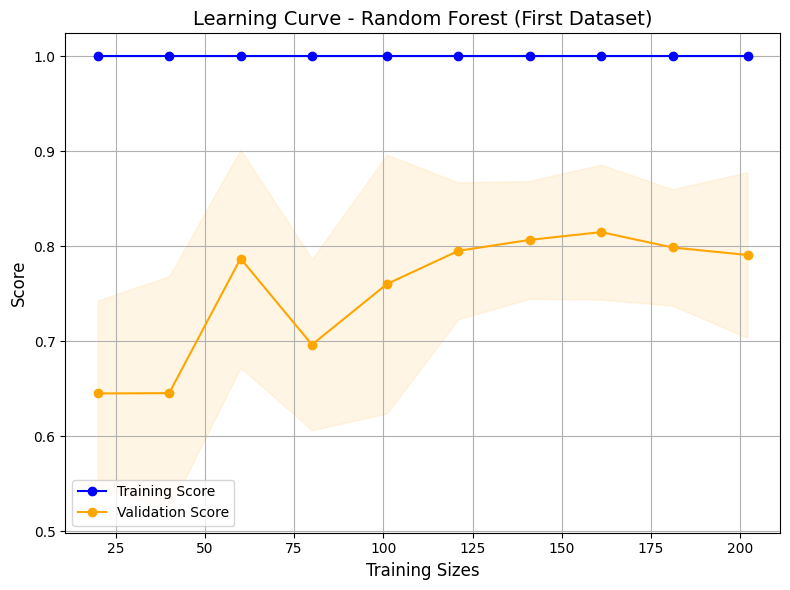

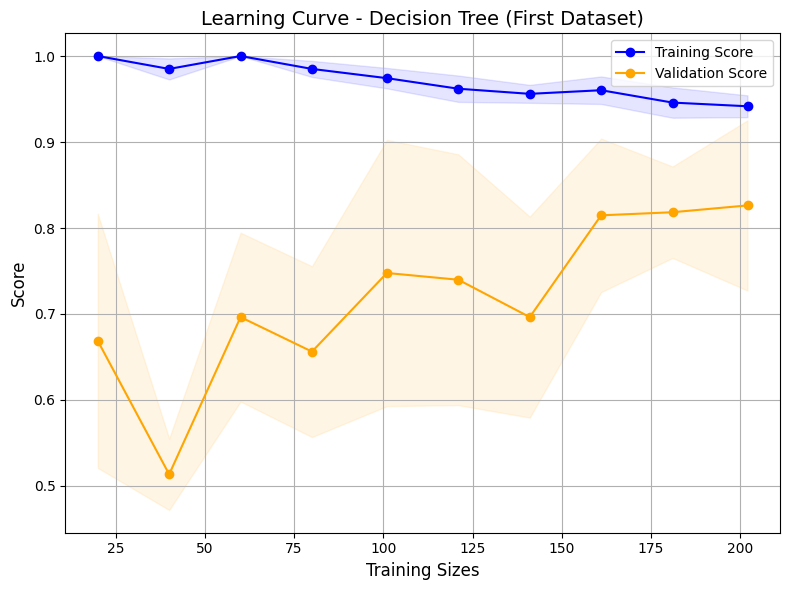

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


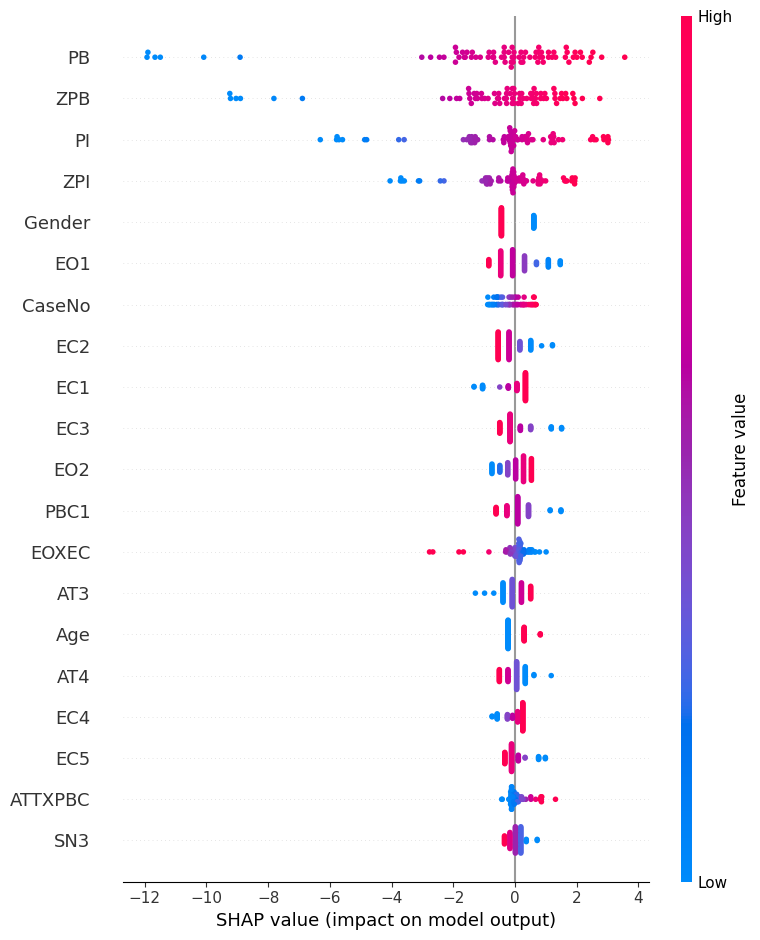


Logistic Regression Results for Second Dataset:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       106
           1       1.00      0.93      0.97        60

    accuracy                           0.98       166
   macro avg       0.98      0.97      0.97       166
weighted avg       0.98      0.98      0.98       166


Random Forest Results for Second Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00        60

    accuracy                           1.00       166
   macro avg       1.00      1.00      1.00       166
weighted avg       1.00      1.00      1.00       166


Decision Tree Results for Second Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00        60

    accuracy                           1.00    

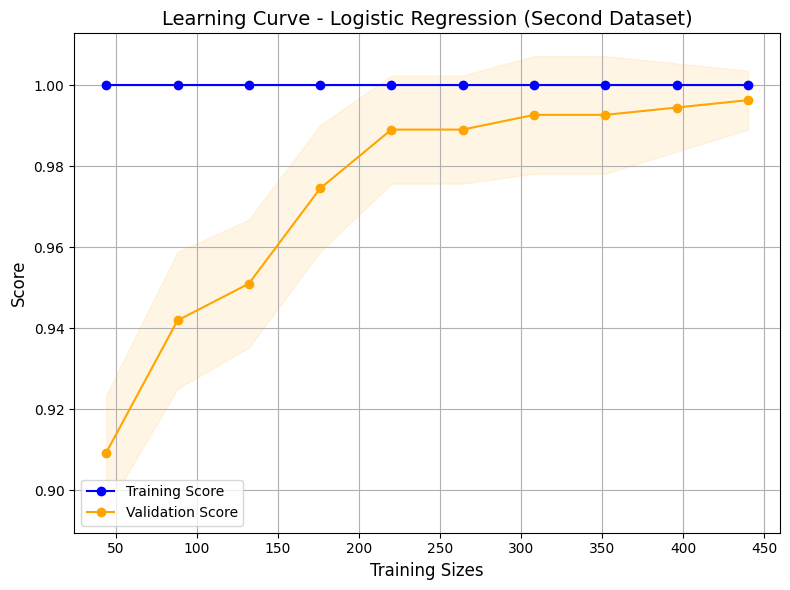

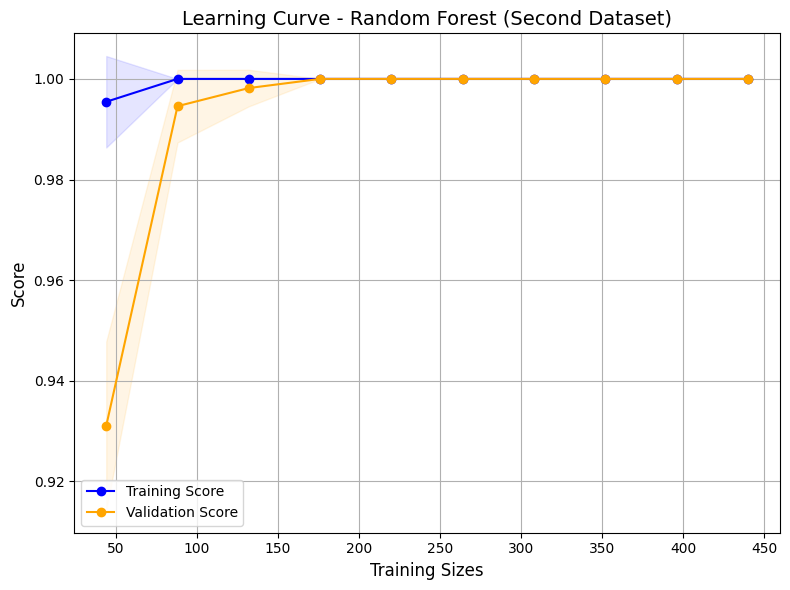

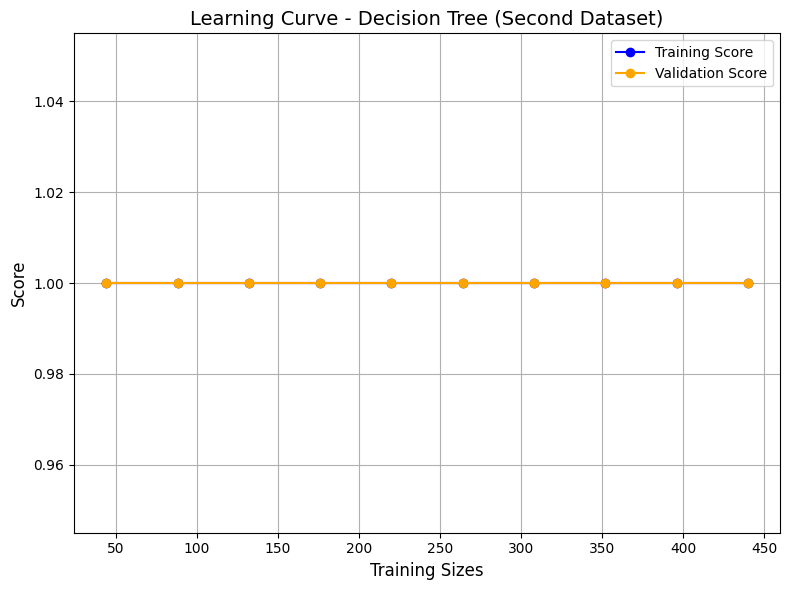

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


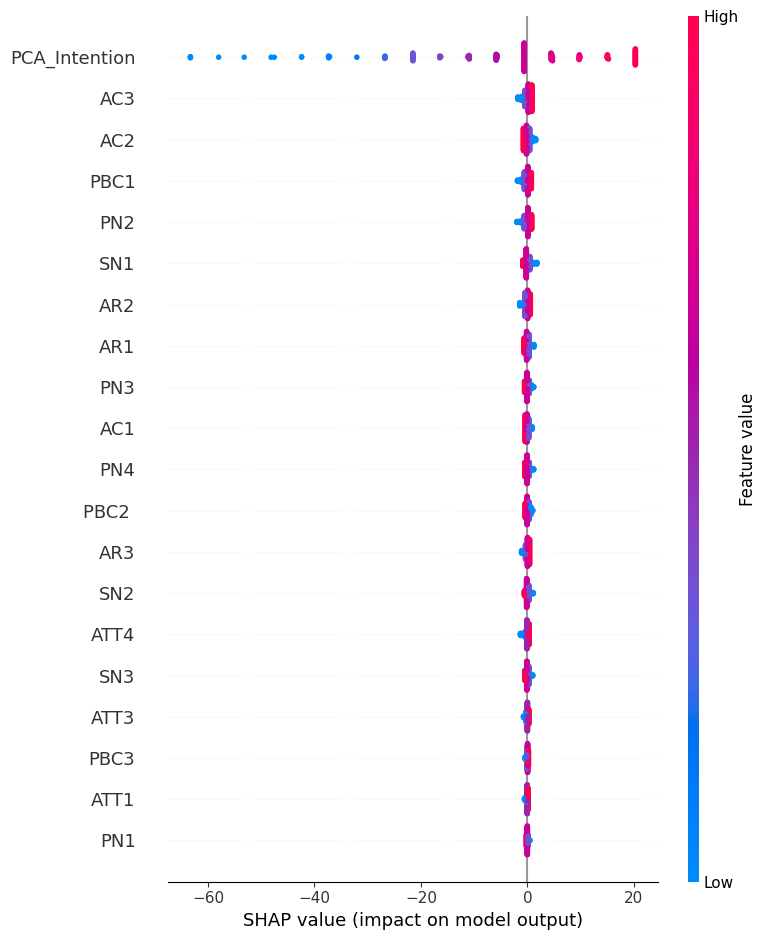

In [ ]:
# -*- coding: utf-8 -*-
"""407 Analysis with Optimizers and Explainable AI"""

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from lime.lime_tabular import LimeTabularExplainer
import shap
from sklearn.decomposition import PCA
from collections import Counter
from imblearn.over_sampling import SMOTE

# Set random seed for reproducibility
np.random.seed(42)

# Load datasets
firstdf = pd.read_csv('/content/Data - Sheet1.csv')
seconddf = pd.read_csv('/content/Data- Sustainable consumption intention in Vietnam - Sheet1.csv')

# Preprocess the first dataset
firstdf['GPI_GPB_Composite'] = firstdf[['GPI1', 'GPI2', 'GPI3', 'GPI4', 'GPB1', 'GPB2', 'GPB3', 'GPB4', 'GPB5', 'GPB6']].mean(axis=1)
threshold = 5.5
firstdf['GPI_GPB_Category'] = firstdf['GPI_GPB_Composite'].apply(lambda x: 1 if x >= threshold else 0)
features_first = [
    'AT1', 'AT2', 'AT3', 'AT4', 'SN1', 'SN2', 'SN3', 'PBC1', 'PBC2',
    'PBC3', 'EO1', 'EO2', 'EO3', 'EC1', 'EC2', 'EC3', 'EC4', 'EC5',
    'Gender', 'Age', 'Marital_Status', 'PB', 'EC', 'EO', 'PI', 'PBC', 'SNs',
    'ATT', 'CaseNo', 'ZPB', 'ZEC', 'ZEO', 'ZPI', 'ZPBC', 'ZSNs', 'ZATT',
    'EOXEC', 'ATTXSN', 'PBCXSN', 'ATTXPBC'
]
X_first = firstdf[features_first]
y_first = firstdf['GPI_GPB_Category']

# Split first dataset
X_train_first, X_test_first, y_train_first, y_test_first = train_test_split(X_first, y_first, test_size=0.3, random_state=42)

# Logistic Regression with Grid Search
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_search_lr.fit(X_train_first, y_train_first)
lr_model = grid_search_lr.best_estimator_
y_pred_lr = lr_model.predict(X_test_first)
print("\nLogistic Regression Results for First Dataset:")
print(classification_report(y_test_first, y_pred_lr))

# Random Forest with Random Search
param_dist_rf = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}
random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=param_dist_rf, n_iter=10, cv=5)
random_search_rf.fit(X_train_first, y_train_first)
rf_model = random_search_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test_first)
print("\nRandom Forest Results for First Dataset:")
print(classification_report(y_test_first, y_pred_rf))

# Decision Tree with Grid Search
param_grid_dt = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5)
grid_search_dt.fit(X_train_first, y_train_first)
dt_model = grid_search_dt.best_estimator_
y_pred_dt = dt_model.predict(X_test_first)
print("\nDecision Tree Results for First Dataset:")
print(classification_report(y_test_first, y_pred_dt))

# Learning Curve Plot Function
def plot_learning_curve(estimator, X, y, title, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, train_sizes=train_sizes, n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Validation Score')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

    plt.title(title, fontsize=14)
    plt.xlabel('Training Sizes', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Learning Curves for First Dataset
plot_learning_curve(lr_model, X_first, y_first, title='Learning Curve - Logistic Regression (First Dataset)')
plot_learning_curve(rf_model, X_first, y_first, title='Learning Curve - Random Forest (First Dataset)')
plot_learning_curve(dt_model, X_first, y_first, title='Learning Curve - Decision Tree (First Dataset)')

# LIME for First Dataset
lime_explainer_first = LimeTabularExplainer(
    X_train_first.values,
    training_labels=y_train_first.values,
    feature_names=X_train_first.columns,
    class_names=['Class 0', 'Class 1'],
    discretize_continuous=True
)
lime_exp_first = lime_explainer_first.explain_instance(
    X_test_first.iloc[0].values,
    lr_model.predict_proba
)
lime_exp_first.show_in_notebook()

# SHAP for First Dataset
shap_explainer_first = shap.Explainer(lr_model, X_train_first)
shap_values_first = shap_explainer_first(X_test_first)
shap.summary_plot(shap_values_first, X_test_first)

# Preprocess the second dataset
pca = PCA(n_components=1)
seconddf['PCA_Intention'] = pca.fit_transform(seconddf[['IN1', 'IN2', 'IN3', 'IN4']])
seconddf['IN_INTENTION'] = (seconddf['PCA_Intention'] >= pca.components_.mean()).astype(int)
X_second = seconddf.drop(columns=['STT', 'IN_INTENTION', 'IN1', 'IN2', 'IN3', 'IN4'])
y_second = seconddf['IN_INTENTION']

# Split second dataset
X_train_second, X_test_second, y_train_second, y_test_second = train_test_split(X_second, y_second, test_size=0.3, random_state=42)

# Logistic Regression with Grid Search
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_search_lr.fit(X_train_second, y_train_second)
lr_model_second = grid_search_lr.best_estimator_
y_pred_lr_second = lr_model_second.predict(X_test_second)
print("\nLogistic Regression Results for Second Dataset:")
print(classification_report(y_test_second, y_pred_lr_second))

# Random Forest with Random Search
param_dist_rf = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}
random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=param_dist_rf, n_iter=10, cv=5)
random_search_rf.fit(X_train_second, y_train_second)
rf_model_second = random_search_rf.best_estimator_
y_pred_rf_second = rf_model_second.predict(X_test_second)
print("\nRandom Forest Results for Second Dataset:")
print(classification_report(y_test_second, y_pred_rf_second))

# Decision Tree with Grid Search
param_grid_dt = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5)
grid_search_dt.fit(X_train_second, y_train_second)
dt_model_second = grid_search_dt.best_estimator_
y_pred_dt_second = dt_model_second.predict(X_test_second)
print("\nDecision Tree Results for Second Dataset:")
print(classification_report(y_test_second, y_pred_dt_second))

# Learning Curves for Second Dataset
plot_learning_curve(lr_model_second, X_second, y_second, title='Learning Curve - Logistic Regression (Second Dataset)')
plot_learning_curve(rf_model_second, X_second, y_second, title='Learning Curve - Random Forest (Second Dataset)')
plot_learning_curve(dt_model_second, X_second, y_second, title='Learning Curve - Decision Tree (Second Dataset)')

# LIME for Second Dataset
lime_explainer_second = LimeTabularExplainer(
    X_train_second.values,
    training_labels=y_train_second.values,
    feature_names=X_train_second.columns,
    class_names=['Class 0', 'Class 1'],
    discretize_continuous=True
)
lime_exp_second = lime_explainer_second.explain_instance(
    X_test_second.iloc[0].values,
    lr_model_second.predict_proba
)
lime_exp_second.show_in_notebook()

# SHAP for Second Dataset
shap_explainer_second = shap.Explainer(lr_model_second, X_train_second)
shap_values_second = shap_explainer_second(X_test_second)
shap.summary_plot(shap_values_second, X_test_second)
